In [1]:
import pandas as pd
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
from scipy.stats import kruskal

Load datasets:

In [2]:
mh = pd.read_csv('data/cleaned_mental_health_data.csv', parse_dates=['Timestamp'])
music = pd.read_csv('data/processed_music_data.csv')

Group Mental Health Score and Music Valence by season in order to perform ACF test and F-test

In [3]:
mh_monthly = mh.groupby(['Season']).composite_mh_score.mean().reset_index()
music_monthly = music.groupby(['season']).valence.mean().reset_index()

# ACF Test

## Mental Health

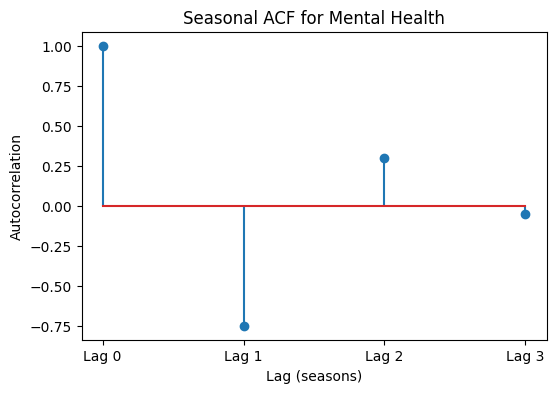

In [4]:
mh_acf = acf(mh_monthly['composite_mh_score'].values, nlags=3)

plt.figure(figsize=(6,4))
plt.stem(range(len(mh_acf)), mh_acf)
plt.xlabel('Lag (seasons)')
plt.ylabel('Autocorrelation')
plt.title('Seasonal ACF for Mental Health')
plt.xticks(range(4), ['Lag 0','Lag 1','Lag 2','Lag 3'])
plt.show()


- The lag-1 value of -0.75 is a strong negative autocorrelation. This means if mental health scores are high one month, they tend to be low the next month, and vice versa. For example, if mental health is low in Winter, it’s likely higher in Spring. 
- The lag-2 value of +0.3 partially recovers (high → low → moderate), meaning mental health has a moderate tendency to return toward the original value.
- The lag-3 value of -0.05 is near zero, meaning that there is little correlation between a season and the season three steps ahead.

Mental health shows clear seasonality: opposite in adjacent seasons and partially recovers two seasons later. This fits the expected seasonal pattern for SAD: winter lows, summer highs.

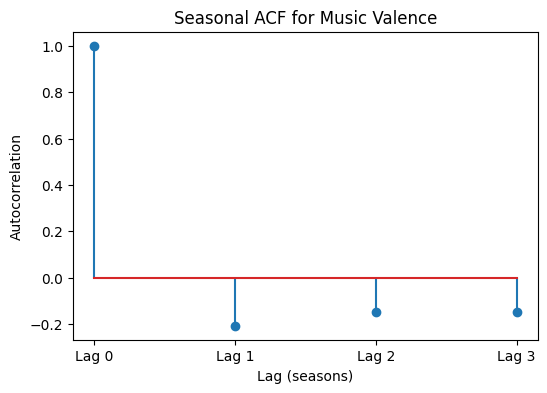

In [5]:
valence_acf = acf(music_monthly['valence'].values, nlags=3)

plt.figure(figsize=(6,4))
plt.stem(range(len(valence_acf)), valence_acf)
plt.xlabel('Lag (seasons)')
plt.ylabel('Autocorrelation')
plt.title('Seasonal ACF for Music Valence')
plt.xticks(range(4), ['Lag 0','Lag 1','Lag 2','Lag 3'])
plt.show()

All three lags are small negative values hovering around -0.15 to -0.21. This means music valence doesn't particularly show a meaningful autocorrelation. Knowing last season's average valence doesn't tell much about this month's. This suggests that people’s music listening habits don't reflect seasonal changes as strongly as mental health does.

# F-test

In [6]:
from scipy.stats import f_oneway

# Group data by season
mh_groups = [group['composite_mh_score'].values for name, group in mh.groupby('Season')]
valence_groups = [group['valence'].values for name, group in music.groupby('season')]

# Perform F-test
f_mh, p_mh = f_oneway(*mh_groups)
f_val, p_val = f_oneway(*valence_groups)

print("F-test for seasonal differences (Mental Health): F =", f_mh, "p =", p_mh)
print("F-test for seasonal differences (Music Valence): F =", f_val, "p =", p_val)

F-test for seasonal differences (Mental Health): F = 259.86468044018784 p = 1.934032410282842e-168
F-test for seasonal differences (Music Valence): F = 4.748093024504282 p = 0.0026335753939980802


The F-test on the mental health dataset produced **F = 259**. This is very high, showing that the differences between seasons are much larger than the variability within each season. With a p-value of virutally 0, we can say that season is a powerful predictor of mental health score.

The F-test on music valence produced **F = 4.75**. While this is not as high as the mental health scores, we obtain a p-value of **0.0026**, which is still evidence to suggest that music valence differs between seasons.

From the F-test, we can conclude that the type of music people listen to does vary slightly across seasons, but the effect is much smaller than the variation in mental health.

# Kruskal-Wallis Test

In [7]:
mh_groups = [group['composite_mh_score'].values 
             for name, group in mh.groupby('Season')]

stat_mh, p_mh = kruskal(*mh_groups)

print("Kruskal-Wallis (Mental Health):")
print("H-statistic:", stat_mh)
print("p-value:", p_mh)

Kruskal-Wallis (Mental Health):
H-statistic: 877.9045601432925
p-value: 5.490406650122106e-190


In [9]:
valence_groups = [group['valence'].values 
                  for name, group in music.groupby('season')]

stat_val, p_val = kruskal(*valence_groups)

print("Kruskal-Wallis (Music Valence):")
print("H-statistic:", stat_val)
print("p-value:", p_val)

Kruskal-Wallis (Music Valence):
H-statistic: 8.65027800121472
p-value: 0.03432079293583533


Because Q-Q plots indicated that the distributions deviate from normality, a Kruskal–Wallis test was performed in addition to the ANOVA F-test. The results were consistent across both tests, confirming that seasonal differences in mental health and music valence are statistically significant.

Our results suggest:

- Mental health clearly changes across seasons globally.
- Music mood (valence) also changes slightly across seasons.
- The seasonal effect is much stronger in mental health than in music listening behavior.

Music might partially reflect seasonal mood shifts, but it might not be a perfect proxy for population mental health.